# Force–Deflection and Noise Simulator
## AFM as a Calibrated Force Sensor

This notebook accompanies Chapter 1 of the textbook *Scanning Probe Microscopy*.

After completing this notebook, you will be able to:

- Convert cantilever deflection into force using Hooke’s law.
- Distinguish between pN, nN, and µN force regimes.
- Estimate thermal RMS force.
- Perform order-of-magnitude sanity checks.
- Understand the trade-off between cantilever stiffness and force sensitivity.

The central idea:  
**At the nanoscale, measurement requires internal calibration.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
k_B = 1.380649e-23  # Boltzmann constant (J/K)
T = 298             # Room temperature (K)

## 1. Hooke’s Law in AFM

The cantilever behaves as a linear spring:

\[
F = k s
\]

where:
- \( F \) = force (N)
- \( k \) = spring constant (N/m)
- \( s \) = deflection (m)

⚠️ Units matter. AFM operates in nanometers, but equations require meters.

In [2]:
def calculate_force(k_N_per_m, deflection_nm):
    deflection_m = deflection_nm * 1e-9
    F = k_N_per_m * deflection_m
    return F

# Example parameters
k = 0.1        # N/m
deflection = 15  # nm

F = calculate_force(k, deflection)

print(f"Force = {F:.2e} N")

# Convert to intuitive units
if F < 1e-9:
    print(f"Force ≈ {F*1e12:.2f} pN")
elif F < 1e-6:
    print(f"Force ≈ {F*1e9:.2f} nN")
else:
    print(f"Force ≈ {F*1e6:.2f} µN")

Force = 1.50e-09 N
Force ≈ 1.50 nN


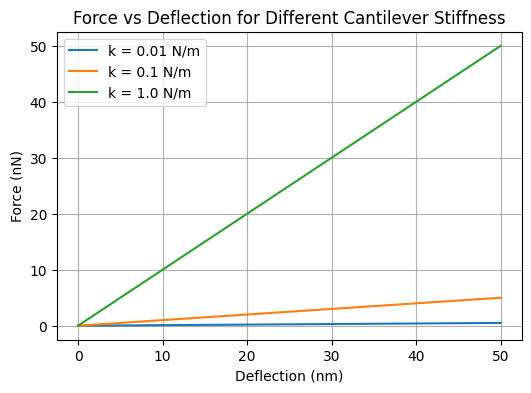

In [3]:
k_values = [0.01, 0.1, 1.0]
deflections_nm = np.linspace(0, 50, 200)

plt.figure(figsize=(6,4))

for k in k_values:
    forces = k * deflections_nm * 1e-9
    plt.plot(deflections_nm, forces*1e9, label=f"k = {k} N/m")

plt.xlabel("Deflection (nm)")
plt.ylabel("Force (nN)")
plt.title("Force vs Deflection for Different Cantilever Stiffness")
plt.legend()
plt.grid(True)
plt.show()

## 2. Order-of-Magnitude Reference

Typical AFM force regimes:

| Quantity                          | Typical Magnitude |
|----------------------------------|------------------|
| Thermal RMS force                | 5–30 pN          |
| Single receptor–ligand bond      | 10–200 pN        |
| Soft-cell indentation force      | 0.5–5 nN         |
| Hard polymer indentation         | 10–100 nN        |

Internal calibration question:
Does your calculated force lie in a physically plausible regime?

In [4]:
def thermal_rms_force(k):
    return np.sqrt(k * k_B * T)

k_test = 0.05
F_rms = thermal_rms_force(k_test)

print(f"Thermal RMS force ≈ {F_rms*1e12:.2f} pN")

Thermal RMS force ≈ 14.34 pN


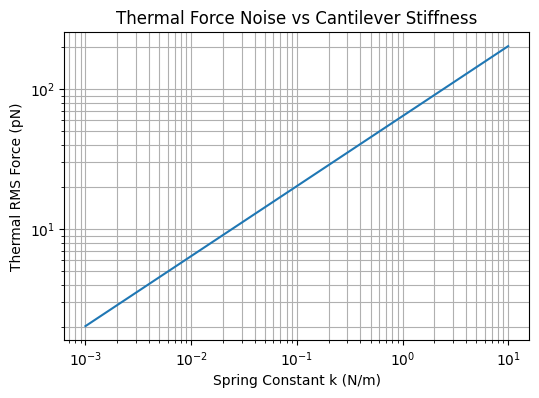

In [5]:
k_range = np.logspace(-3, 1, 200)
F_noise = np.sqrt(k_range * k_B * T)

plt.figure(figsize=(6,4))
plt.loglog(k_range, F_noise*1e12)
plt.xlabel("Spring Constant k (N/m)")
plt.ylabel("Thermal RMS Force (pN)")
plt.title("Thermal Force Noise vs Cantilever Stiffness")
plt.grid(True, which="both")
plt.show()

In [6]:
# Hypothetical incorrect student result
reported_force = 80e-6  # 80 µN

print(f"Reported force = {reported_force*1e6:.1f} µN")

# Compare with soft cell regime (~1 nN)
ratio = reported_force / 1e-9
print(f"This is {ratio:.1e} times larger than typical soft-cell forces.")

Reported force = 80.0 µN
This is 8.0e+04 times larger than typical soft-cell forces.


If a live cell requires 80 µN for 100 nm indentation, this exceeds typical values by 4–5 orders of magnitude.

Likely errors:
- nm not converted to m
- µm confused with nm
- Young’s modulus in kPa treated as Pa
- Deflection confused with indentation

## Engineering Insight

Higher spatial resolution does not automatically imply higher mechanical accuracy.

- Stiffer cantilever → larger forces
- Sharper tip → higher local stress
- Softer cantilever → lower force but increased instability

Quantitative nanoscale measurement is always a trade-off between:
- Sensitivity
- Stability
- Perturbation
- Noise

# Summary

AFM is fundamentally a calibrated force sensor.

Key principles:
- Always convert to SI units.
- Check order of magnitude before trusting a result.
- Compare signal magnitude to thermal noise.
- Choose cantilever stiffness based on force regime.

Measurement at the nanoscale is interaction-based metrology.